In [1]:
import pandas as pd

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns


In [3]:

try:
    from dotenv import load_dotenv, find_dotenv
    import os

    if not load_dotenv():
        load_dotenv(find_dotenv())


    HOST = os.getenv("HOST")
    if HOST is None:
        print("Variables not found. Check .env")

    else:
        PORT = os.getenv("PORT")
        USERNAME = os.getenv("USERNAME")
        PASSWORD = os.getenv("PASSWORD")
        DATABASE = os.getenv("DATABASE")

except:
    print("Cant load env")

In [4]:
import mysql.connector
from mysql.connector import Error

connection = mysql.connector.connect(
    host=HOST,
    port=PORT,
    user=USERNAME,
    password=PASSWORD,
    database=DATABASE
)

cursor = connection.cursor()
if connection.is_connected():
    print("Connected")

else:
    print("Not connected, check server or credentials")

Connected


In [5]:
cursor.execute("SHOW TABLES;")
tables = [row[0] for row in cursor.fetchall()]

In [6]:
schema = {}

for table in tables:
    cursor.execute(f"""
        SELECT COLUMN_NAME, DATA_TYPE, IS_NULLABLE, COLUMN_KEY, COLUMN_DEFAULT
        FROM INFORMATION_SCHEMA.COLUMNS
        WHERE TABLE_SCHEMA = DATABASE()
        AND TABLE_NAME = %s
        ORDER BY ORDINAL_POSITION;
    """, (table,))
    
    columns = cursor.fetchall()
    schema[table] = columns

    print(f"\nTable: {table}")
    for col_name, data_type, nullable, key, default in columns:
        key_marker = f" [{key}]" if key else ""
        print(f"  - {col_name} ({data_type}){key_marker}")


Table: catalogue
  - collection_id (varchar) [PRI]
  - title (varchar)
  - constellation (varchar)
  - instruments (varchar)
  - processing_level (varchar)
  - gsd_min_m (decimal)
  - gsd_max_m (decimal)
  - n_bands (smallint)
  - band_names (text)
  - temporal_start (datetime)
  - temporal_end (datetime)
  - bbox (varchar)
  - license (varchar)
  - doi (varchar)
  - providers (varchar)
  - keywords (varchar)

Table: landcover
  - id (int) [PRI]
  - longitude (decimal) [MUL]
  - latitude (decimal)
  - class_code (tinyint)
  - class_name (varchar)

Table: terrain
  - id (int) [PRI]
  - longitude (decimal) [MUL]
  - latitude (decimal)
  - elevation_m (decimal)

Table: training_table
  - id (int) [PRI]
  - longitude (decimal) [MUL]
  - latitude (decimal)
  - elevation_m (decimal)
  - slope_deg (decimal)
  - land_cover_code (tinyint)
  - land_cover_class (varchar)
  - is_built_up (tinyint)


In [7]:
dfs = {}

for table_name, table_info in schema.items():
    query = f"SELECT * FROM {table_name}"
    dfs[table_name] = pd.read_sql(query, connection)

/tmp/ipykernel_5128/3869150288.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs[table_name] = pd.read_sql(query, connection)


In [19]:
def plot_corr_heatmap(df):
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(18, 14))

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        annot_kws={"size": 8},
        square=False
    )

    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.title("Correlation Heatmap", fontsize=16)

    plt.tight_layout()
    plt.show()

In [14]:
dfs["training_table"]

,id,longitude,latitude,elevation_m,slope_deg,land_cover_code,land_cover_class,is_built_up
0,1179632,12.500042,55.699958,36.19,0.68,10,Tree cover,0
1,1179633,12.500125,55.699958,36.19,0.68,10,Tree cover,0
2,1179634,12.500208,55.699958,36.19,0.68,10,Tree cover,0
3,1179635,12.500292,55.699958,36.19,0.68,50,Built-up,1
4,1179636,12.500375,55.699958,36.19,0.68,50,Built-up,1
...,...,...,...,...,...,...,...,...
575995,1755627,12.579625,55.650042,5.64,7.27,10,Tree cover,0
575996,1755628,12.579708,55.650042,5.64,7.27,10,Tree cover,0
575997,1755629,12.579792,55.650042,5.64,7.27,10,Tree cover,0
575998,1755630,12.579875,55.650042,5.64,7.27,10,Tree cover,0


In [15]:
dfs["training_table"] = dfs["training_table"].drop(columns="land_cover_class")

In [16]:
dfs["training_table"]

,id,longitude,latitude,elevation_m,slope_deg,land_cover_code,is_built_up
0,1179632,12.500042,55.699958,36.19,0.68,10,0
1,1179633,12.500125,55.699958,36.19,0.68,10,0
2,1179634,12.500208,55.699958,36.19,0.68,10,0
3,1179635,12.500292,55.699958,36.19,0.68,50,1
4,1179636,12.500375,55.699958,36.19,0.68,50,1
...,...,...,...,...,...,...,...
575995,1755627,12.579625,55.650042,5.64,7.27,10,0
575996,1755628,12.579708,55.650042,5.64,7.27,10,0
575997,1755629,12.579792,55.650042,5.64,7.27,10,0
575998,1755630,12.579875,55.650042,5.64,7.27,10,0


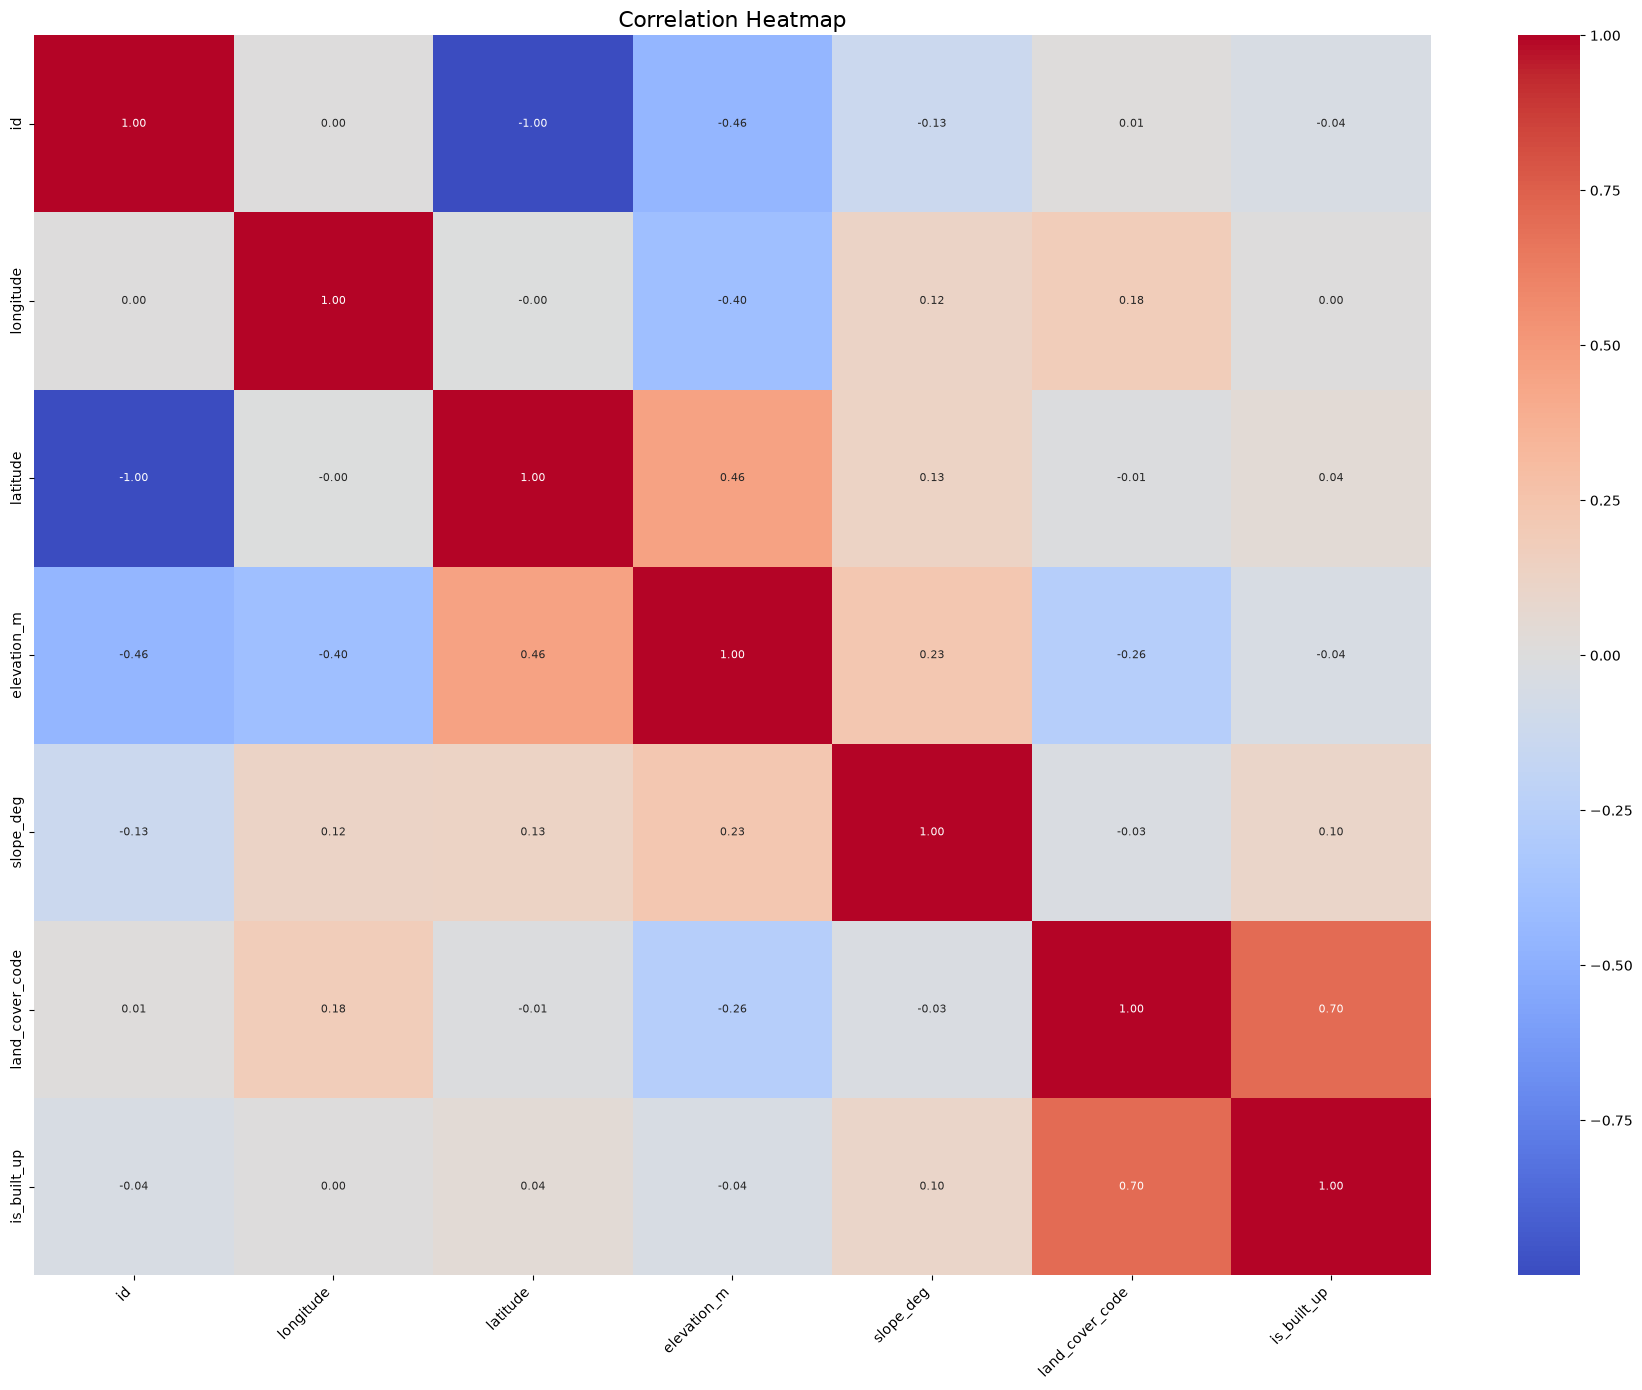

In [20]:
plot_corr_heatmap(dfs["training_table"])